In [60]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import multivariate_normal
from torch.utils.data import DataLoader
from torch.optim import Adam
from vae.models import GaussVAE
from vae.trainers import GaussVAETrainer
from vae.neural_networks import EncoderGaussVAE, DecoderGaussVAE
from data.simple_geometry import (
    Superposition2D, Triforce, Stickman, DeathlyHallows, PlayStation
)
from data.transformations import ScaledTranslation, Rotation
from pathlib import Path

# Data

In [2]:
size = 50000
sigma = 0.025

dataset = PlayStation()
dataset.sample(size, sigma)

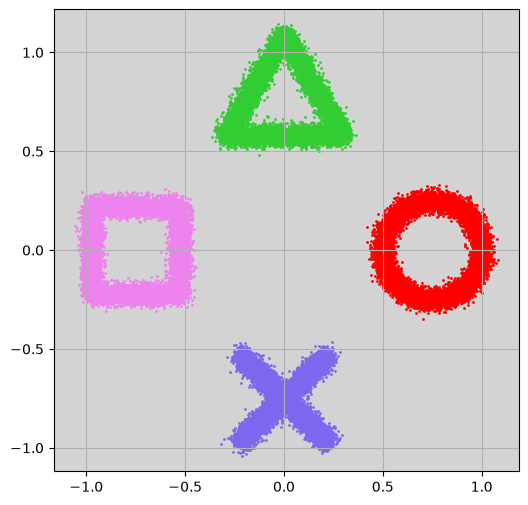

In [3]:
dataset.shape.plot(colour=["red", "violet", "limegreen", "mediumslateblue"])
# dataset.plot()
plt.axis("equal")
plt.show()

# Model

In [4]:
data_dim = 2
latent_dim = 2

encoder = EncoderGaussVAE(data_dim, latent_dim)
decoder = DecoderGaussVAE(data_dim, latent_dim)
encoder_decoder = nn.ModuleDict({
    "encoder" : encoder, 
    "decoder" : decoder
})

In [5]:
sigma = 0.025
model = GaussVAE(encoder, decoder, sigma)

# Training

In [6]:
batch_size = 8
lr = 1e-4

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
optimizer = Adam(encoder_decoder.parameters(), lr=lr)
trainer = GaussVAETrainer(model, dataloader, optimizer)

In [7]:
n_epochs = 10
n_latent = 64
log_dir = Path("/Users/aymanchaouki/Documents/Personal/projects/generative-models/runs/")
n_log = 1

trainer.train(n_epochs, n_latent, log_dir, n_log)

# Evaluation

In [8]:
n_samples = 10000
X_sampled = model.sample(n_samples)

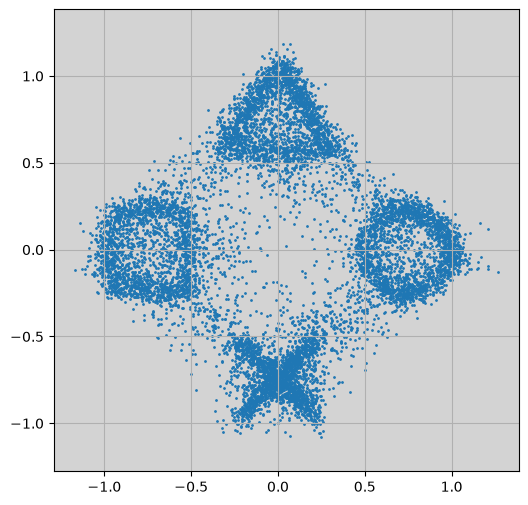

In [9]:
fig_size = (6, 6)
fig, ax = plt.subplots(1, 1, figsize=fig_size)
ax.scatter(X_sampled[:, 0], X_sampled[:, 1], s=1)
ax.grid()

ax.set_facecolor("lightgrey")
plt.axis("equal")
plt.show()

# Analysis of the latent structure

## Modes of the latent conditional $p_{\mathrm{encoder}}\left( Z | X\right)$

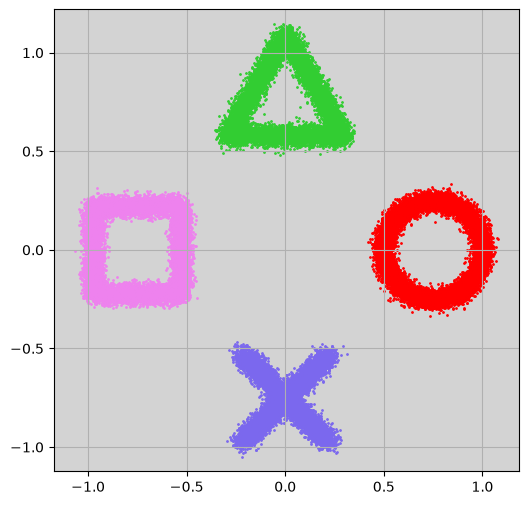

In [36]:
dataset.sample(size, sigma)
dataset.shape.plot(colour=["red", "violet", "limegreen", "mediumslateblue"])
# dataset.plot()
plt.axis("equal")
plt.show()

In [44]:
quotient, remainder = divmod(size, dataset.shape.n_shapes)
shape_names = ["circle", "square", "triangle", "cross"]
shape_colours = ["red", "violet", "limegreen", "mediumslateblue"]
shape_points = {}
for i, shape_name in enumerate(shape_names):
    shape_size = quotient if i < dataset.shape.n_shapes-1 else quotient + remainder
    shape_points[shape_name] = dataset.X[i*quotient : i*quotient + shape_size, :]

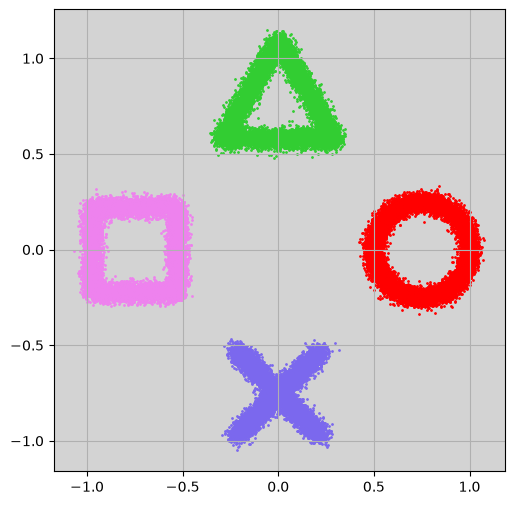

In [56]:
from data.utils import plot2D

ax1 = None
fig_size = (6, 6)
for i, shape_name in enumerate(shape_points):
    ax1 = plot2D(shape_points[shape_name], ax1, fig_size, shape_colours[i])

plt.show()

In [57]:
encoded_shapes = {}
for shape_name in shape_points:
    with torch.no_grad():
        encoded_shapes[shape_name] = model.encoder(torch.from_numpy(shape_points[shape_name]))[0].numpy()

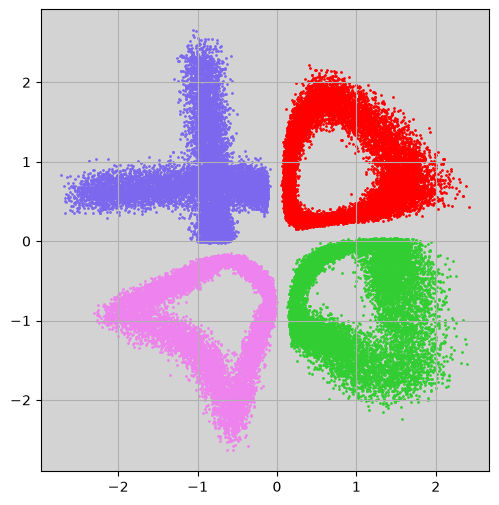

In [61]:
fig_size = (6, 6)
fig, ax2 = plt.subplots(1, 1, figsize=fig_size)
ax2.grid()
ax2.set_facecolor("lightgrey")
ax2.set_aspect("equal")
for i, shape_name in enumerate(encoded_shapes):
    ax2.scatter(encoded_shapes[shape_name][:, 0], encoded_shapes[shape_name][:, 1], s=1, c=shape_colours[i])

plt.show()

## Latent Marginal $p_{\mathrm{encoder}}\left( Z\right)$

In [159]:
from tqdm import tqdm
from torch.distributions.multivariate_normal import MultivariateNormal

def encoder_marginal(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    z = torch.from_numpy(np.hstack((x.reshape((-1, 1)), y.reshape((-1, 1)))))
    log_probs = np.zeros(z.shape[0])
    for i in tqdm(range(dataset.X.shape[0]), desc="log-probabilities"):
        e = MultivariateNormal(gauss_params[0][i], torch.diag(torch.exp(gauss_params[1][i])))
        log_probs += e.log_prob(z).numpy()

    log_probs /= dataset.X.shape[0]
    return log_probs

In [160]:
x = np.linspace(-2.5, 2.5, 1000)
y = np.linspace(-2.5, 2.5, 1000)
X, Y = np.meshgrid(x, y)

In [161]:
z = torch.from_numpy(np.hstack((X.reshape((-1, 1)), Y.reshape((-1, 1)))))

In [165]:
Z = encoder_marginal(X, Y)

log-probabilities: 100%|██████████| 50000/50000 [15:20<00:00, 54.32it/s]


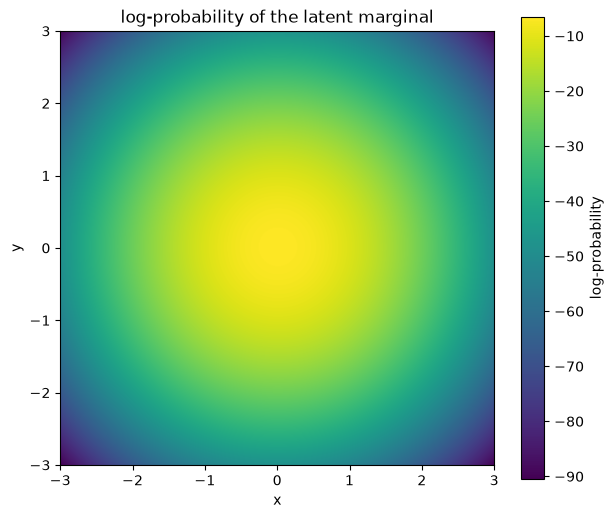

In [169]:
fig, ax = plt.subplots(figsize=(7, 6))

c = ax.imshow(
    Z.reshape((1000, 1000)),
    extent=[-3, 3, -3, 3],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)
fig.colorbar(c, ax=ax, label="log-probability")
ax.set_title("log-probability of the latent marginal")
ax.set_xlabel("x")
ax.set_ylabel("y")

plt.show()